# GAN Image Inpainting — Evaluation

Load the trained GAN model and evaluate on CelebA-HQ with three mask conditions (small / medium / large).
- Visualize inpainting results
- Show stochastic diversity (multiple completions from same input)
- Compute MSE, SSIM, LPIPS metrics

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

from src.shared.dataset import CelebAHQDataset
from src.shared.mask import generate_mask, apply_mask, batch_masks
from src.shared.evaluate import evaluate_all
from src.GAN.model import Generator

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

## 1. Load Model

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

G = Generator(in_ch=4, base_ch=48, noise_dim=32).to(device)
ckpt = torch.load('../models/gan/ckpt_epoch030.pt', map_location=device)
G.load_state_dict(ckpt['G'])
G.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]}')
print(f'Generator params: {sum(p.numel() for p in G.parameters())/1e6:.1f}M')

Device: cuda
Loaded checkpoint from epoch 30
Generator params: 21.2M


In [3]:
dataset = CelebAHQDataset('../data/celeba_hq/celeba_hq_256', image_size=256)
print(f'Dataset size: {len(dataset)}')

Dataset size: 30000


## 2. Inpainting Results (Small / Medium / Large masks)

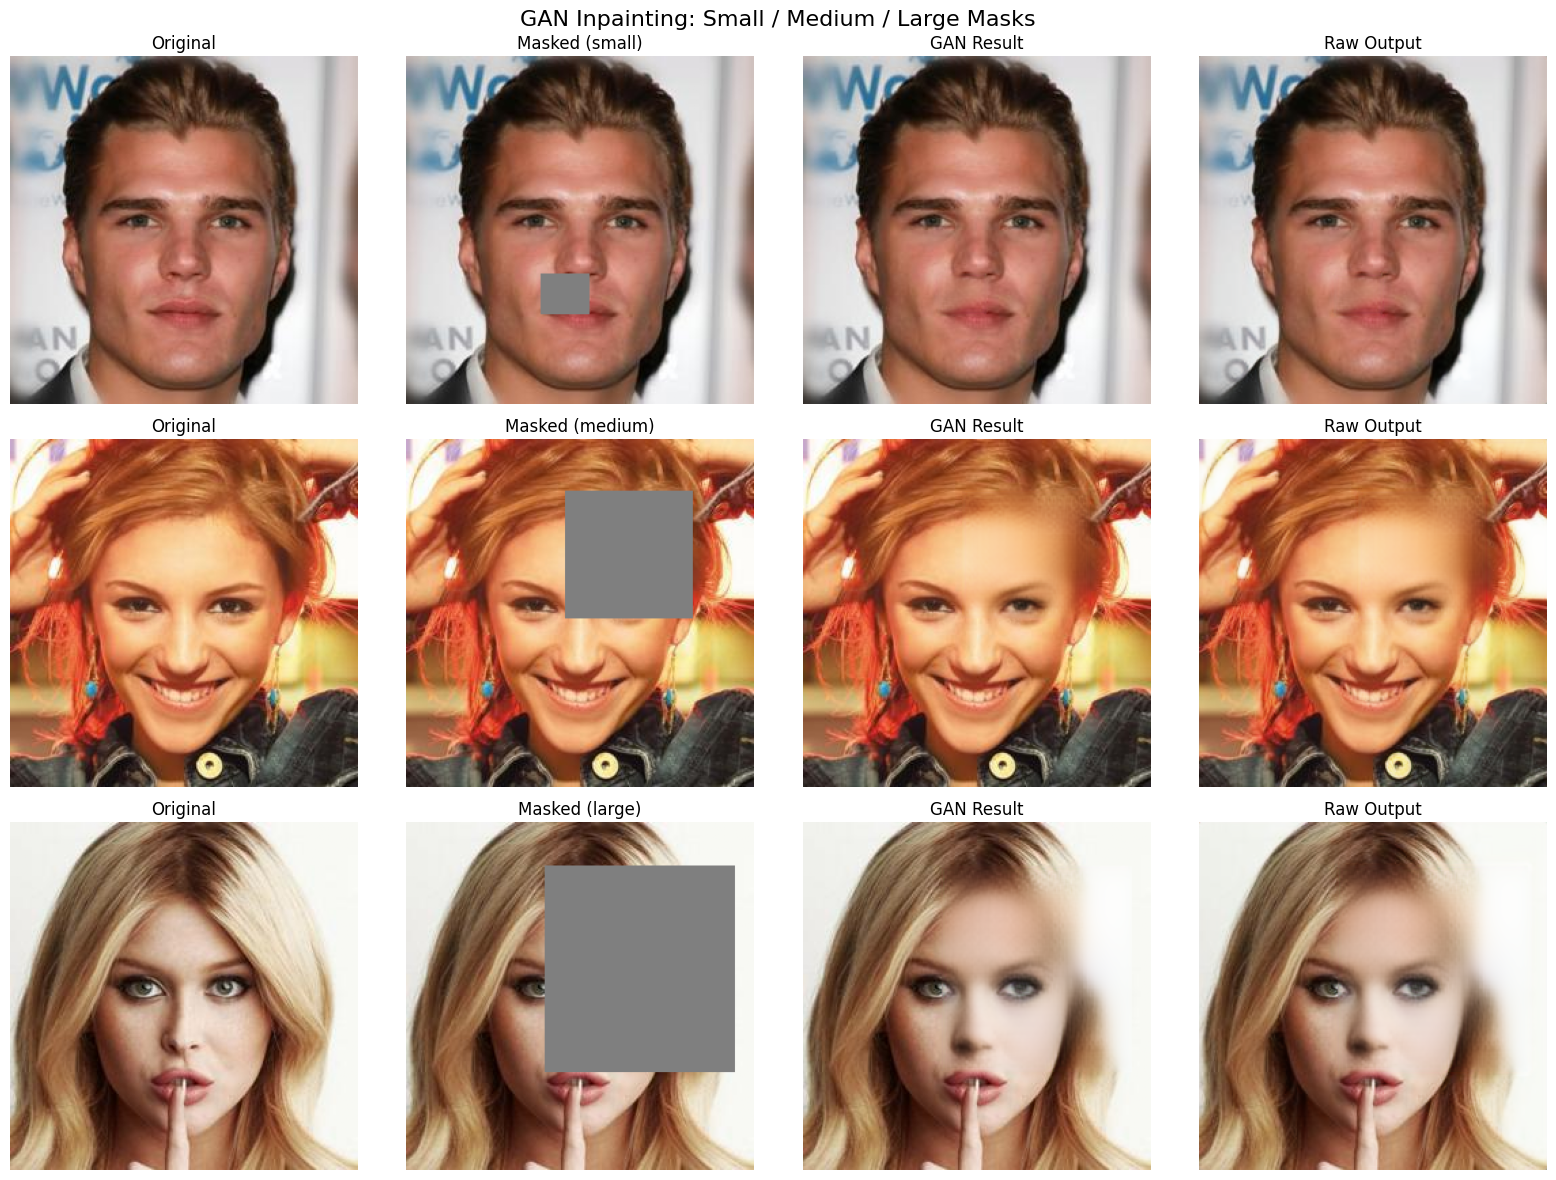

In [4]:
def to_img(t):
    """Convert tensor [-1,1] to displayable numpy [0,1]."""
    return (t.squeeze().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
conditions = ['small', 'medium', 'large']

for row, cond in enumerate(conditions):
    idx = row + 10  # pick different images
    x = dataset[idx].unsqueeze(0).to(device)
    mask = generate_mask(256, 256, condition=cond).unsqueeze(0).to(device)
    y = x * (1 - mask)

    with torch.no_grad():
        x_hat = G(y, mask)
    comp = y * (1 - mask) + x_hat * mask

    axes[row][0].imshow(to_img(x));       axes[row][0].set_title('Original');    axes[row][0].axis('off')
    axes[row][1].imshow(to_img(y));       axes[row][1].set_title(f'Masked ({cond})'); axes[row][1].axis('off')
    axes[row][2].imshow(to_img(comp));    axes[row][2].set_title('GAN Result');   axes[row][2].axis('off')
    axes[row][3].imshow(to_img(x_hat));   axes[row][3].set_title('Raw Output');   axes[row][3].axis('off')

plt.suptitle('GAN Inpainting: Small / Medium / Large Masks', fontsize=16)
plt.tight_layout()
plt.savefig('../results/gan/inpainting_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Stochastic Diversity

Same masked input, multiple different completions — demonstrates that GAN output is stochastic.

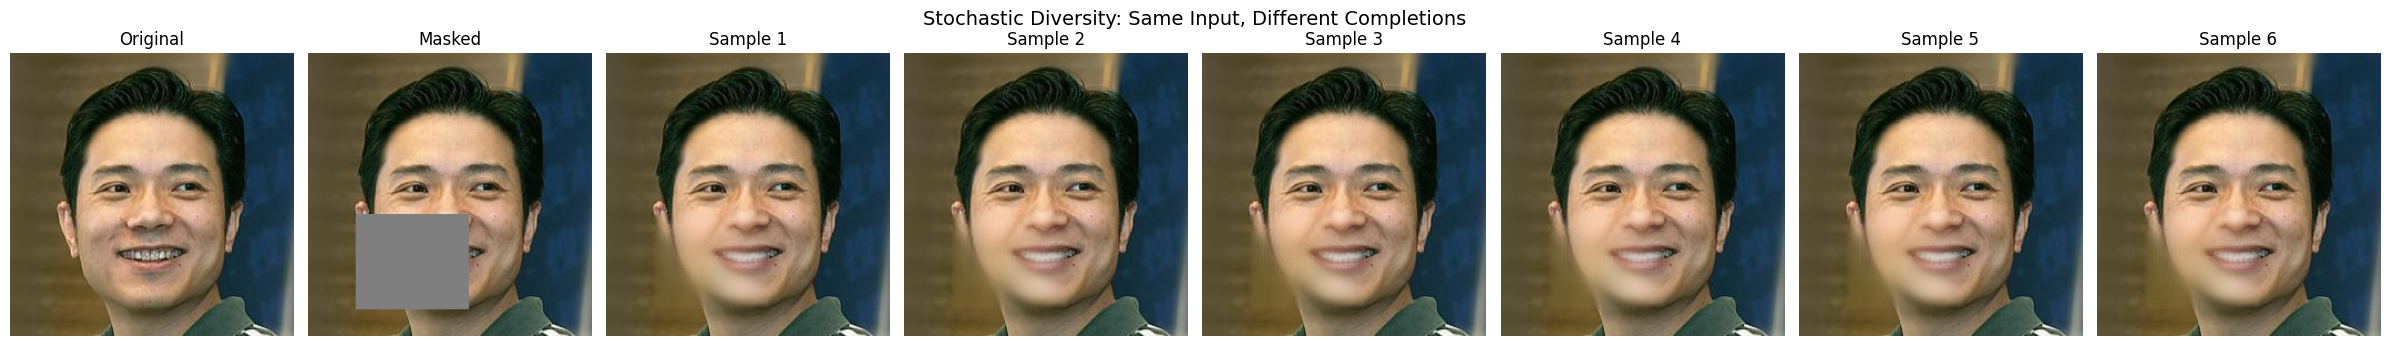

In [5]:
x = dataset[0].unsqueeze(0).to(device)
mask = generate_mask(256, 256, condition='medium').unsqueeze(0).to(device)
y = x * (1 - mask)

n_samples = 6
fig, axes = plt.subplots(1, n_samples + 2, figsize=(24, 3.5))

axes[0].imshow(to_img(x));  axes[0].set_title('Original');  axes[0].axis('off')
axes[1].imshow(to_img(y));  axes[1].set_title('Masked');     axes[1].axis('off')

with torch.no_grad():
    for i in range(n_samples):
        x_hat = G(y, mask)  # different noise each time
        comp = y * (1 - mask) + x_hat * mask
        axes[i + 2].imshow(to_img(comp))
        axes[i + 2].set_title(f'Sample {i+1}')
        axes[i + 2].axis('off')

plt.suptitle('Stochastic Diversity: Same Input, Different Completions', fontsize=14)
plt.tight_layout()
plt.savefig('../results/gan/stochastic_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Quantitative Evaluation (MSE / SSIM / LPIPS)

Evaluate on 1000 images across all three mask conditions.

In [6]:
try:
    import lpips
    lpips_fn = lpips.LPIPS(net='alex').to(device)
    print('LPIPS loaded')
except ImportError:
    print('lpips not installed, run: pip install lpips')
    lpips_fn = None

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\Max\miniconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Max\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Max/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:04<00:00, 50.8MB/s] 


Loading model from: c:\Users\Max\miniconda3\Lib\site-packages\lpips\weights\v0.1\alex.pth
LPIPS loaded


In [7]:
eval_size = 1000
eval_dataset = Subset(dataset, range(eval_size))
eval_loader = DataLoader(eval_dataset, batch_size=16, shuffle=False, num_workers=0)

results = {}

for cond in ['small', 'medium', 'large']:
    mse_list, ssim_list, lpips_list = [], [], []

    for real_imgs in eval_loader:
        real_imgs = real_imgs.to(device)
        B, _, H, W = real_imgs.shape

        masks = batch_masks(B, H, W, condition=cond).to(device)
        masked_imgs = apply_mask(real_imgs, masks)

        with torch.no_grad():
            fake_imgs = G(masked_imgs, masks)
        comp_imgs = real_imgs * (1 - masks) + fake_imgs * masks

        metrics = evaluate_all(real_imgs, comp_imgs, lpips_fn=lpips_fn)
        mse_list.append(metrics['mse'])
        ssim_list.append(metrics['ssim'])
        if 'lpips' in metrics:
            lpips_list.append(metrics['lpips'])

    results[cond] = {
        'MSE': np.mean(mse_list),
        'SSIM': np.mean(ssim_list),
    }
    if lpips_list:
        results[cond]['LPIPS'] = np.mean(lpips_list)

# Print results table
print(f'{"Condition":>10s}  {"MSE":>10s}  {"SSIM":>10s}  {"LPIPS":>10s}')
print('-' * 48)
for cond in ['small', 'medium', 'large']:
    r = results[cond]
    lpips_str = f'{r["LPIPS"]:10.4f}' if 'LPIPS' in r else '       N/A'
    print(f'{cond:>10s}  {r["MSE"]:10.6f}  {r["SSIM"]:10.4f}  {lpips_str}')

 Condition         MSE        SSIM       LPIPS
------------------------------------------------
     small    0.000491      0.9930      0.0053
    medium    0.005184      0.9537      0.0402
     large    0.021958      0.8627      0.1286


## 5. Metrics Bar Chart

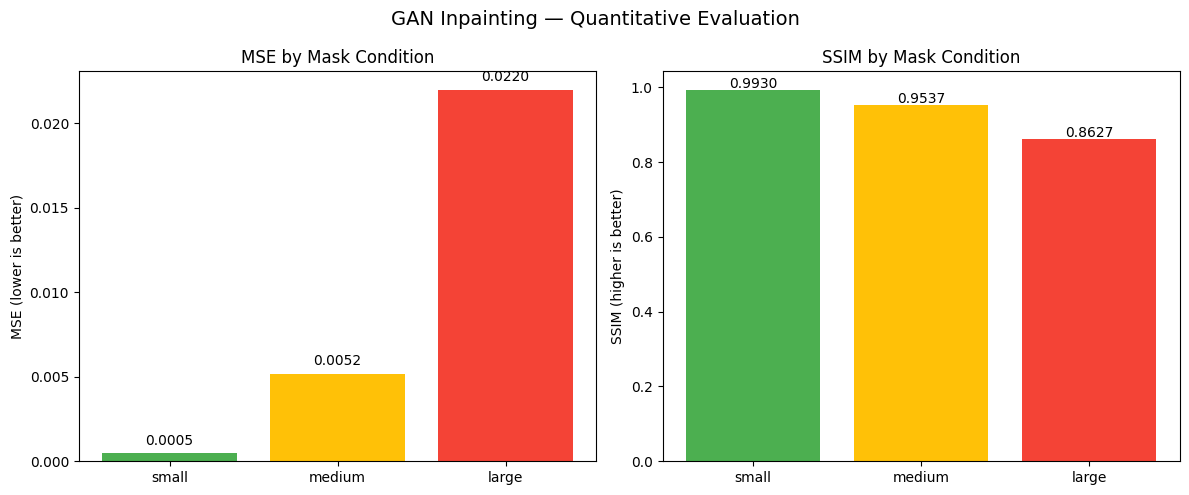

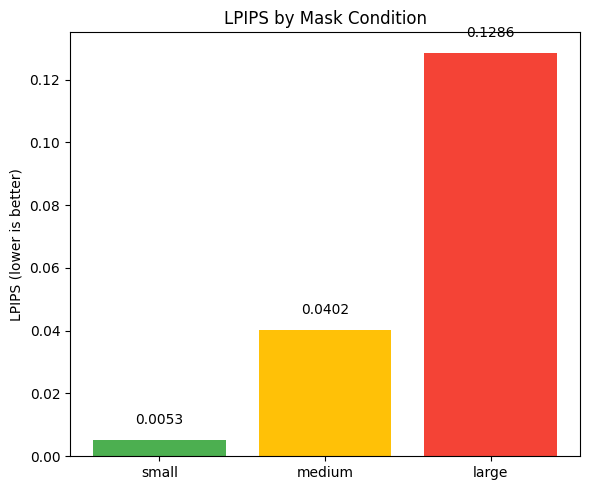

In [8]:
conditions = ['small', 'medium', 'large']
mse_vals = [results[c]['MSE'] for c in conditions]
ssim_vals = [results[c]['SSIM'] for c in conditions]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(conditions, mse_vals, color=['#4CAF50', '#FFC107', '#F44336'])
ax1.set_title('MSE by Mask Condition')
ax1.set_ylabel('MSE (lower is better)')
for i, v in enumerate(mse_vals):
    ax1.text(i, v + 0.0005, f'{v:.4f}', ha='center')

ax2.bar(conditions, ssim_vals, color=['#4CAF50', '#FFC107', '#F44336'])
ax2.set_title('SSIM by Mask Condition')
ax2.set_ylabel('SSIM (higher is better)')
for i, v in enumerate(ssim_vals):
    ax2.text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.suptitle('GAN Inpainting — Quantitative Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('../results/gan/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# LPIPS chart if available
if 'LPIPS' in results['small']:
    lpips_vals = [results[c]['LPIPS'] for c in conditions]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.bar(conditions, lpips_vals, color=['#4CAF50', '#FFC107', '#F44336'])
    ax.set_title('LPIPS by Mask Condition')
    ax.set_ylabel('LPIPS (lower is better)')
    for i, v in enumerate(lpips_vals):
        ax.text(i, v + 0.005, f'{v:.4f}', ha='center')
    plt.tight_layout()
    plt.savefig('../results/gan/lpips_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. More Samples (for Report)

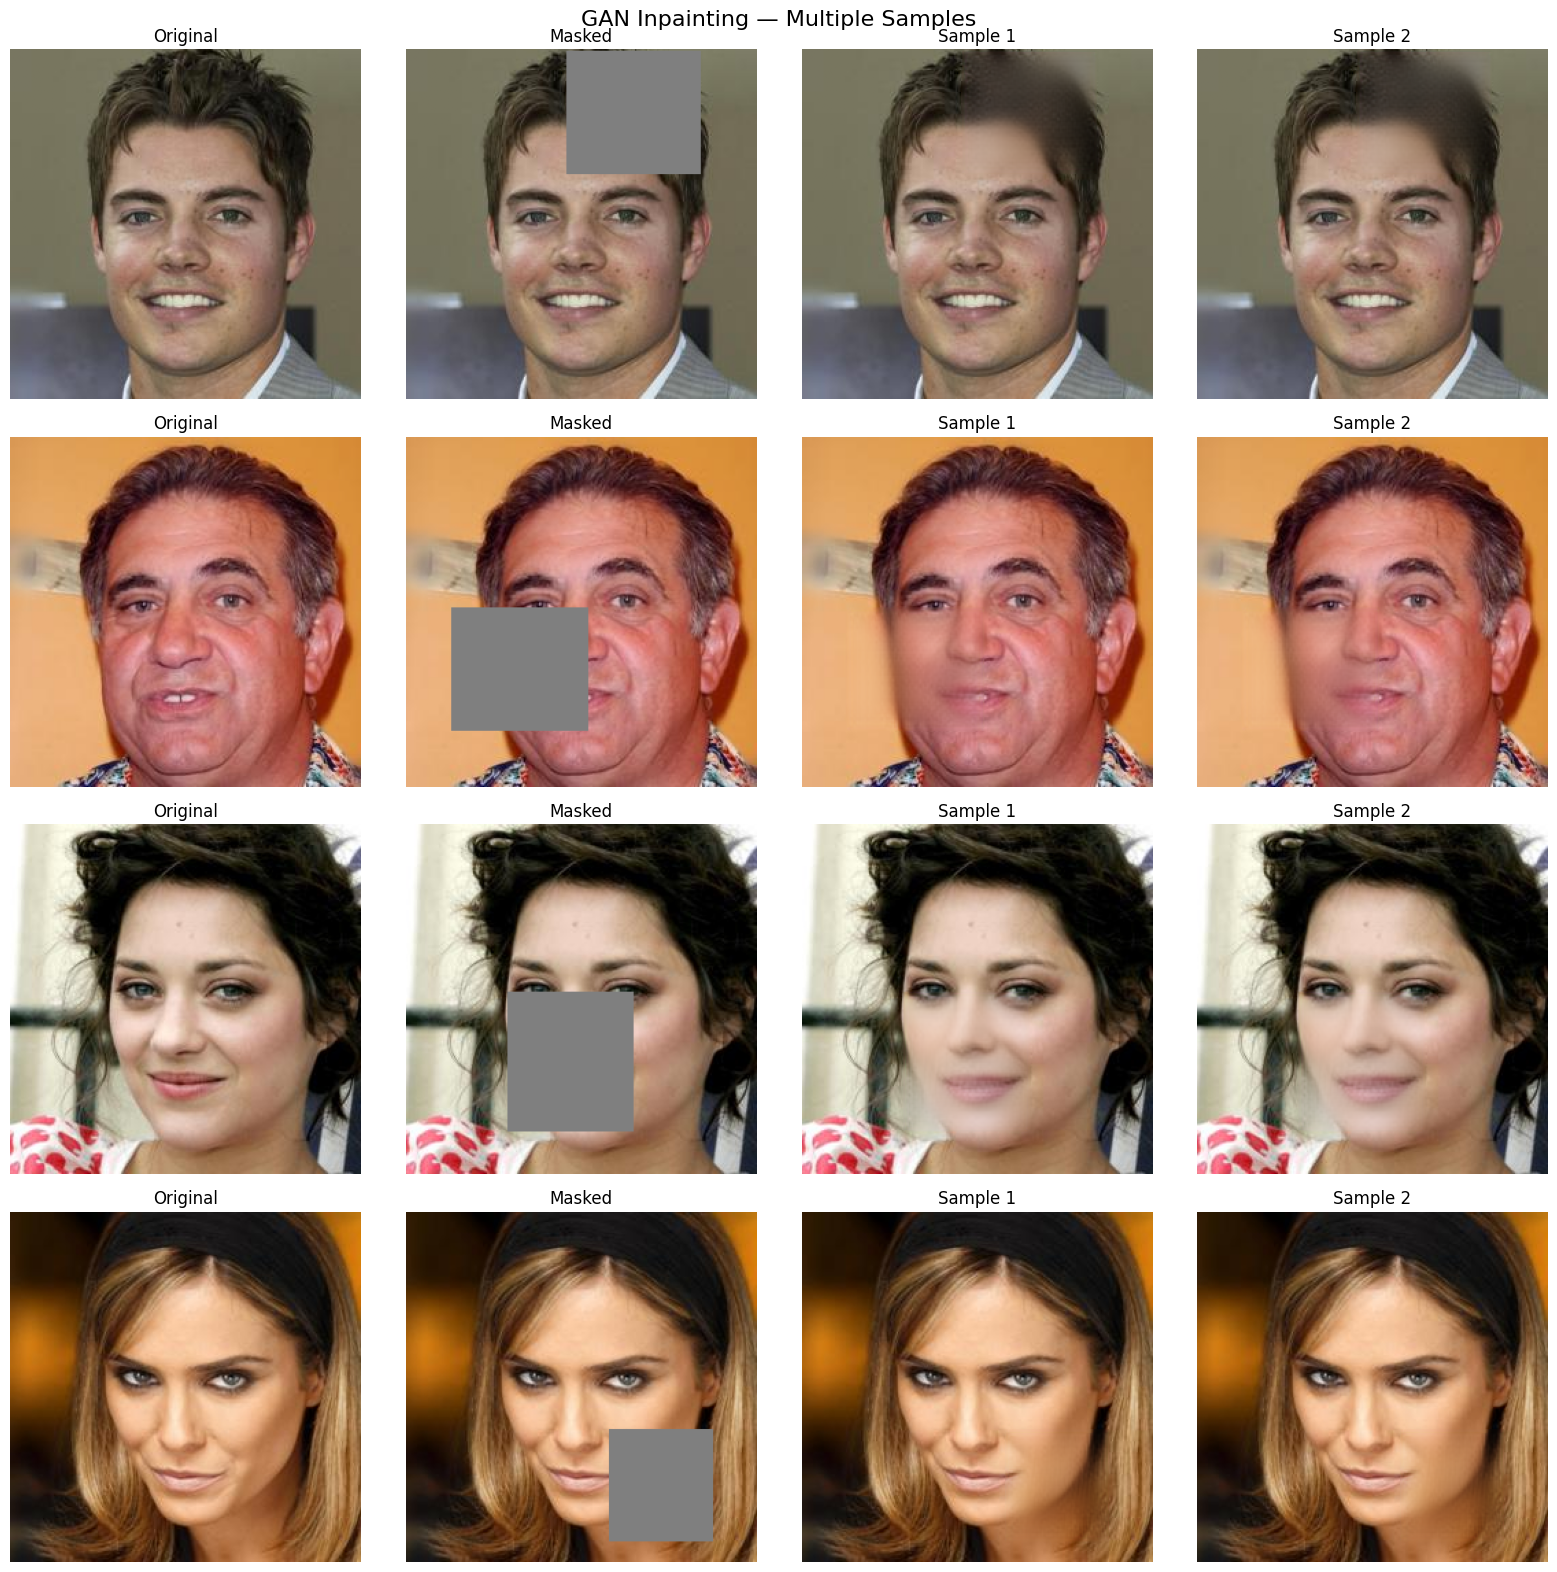

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for row in range(4):
    idx = row * 50 + 5
    x = dataset[idx].unsqueeze(0).to(device)
    mask = generate_mask(256, 256, condition='medium').unsqueeze(0).to(device)
    y = x * (1 - mask)

    with torch.no_grad():
        x_hat1 = G(y, mask)
        x_hat2 = G(y, mask)
    comp1 = y * (1 - mask) + x_hat1 * mask
    comp2 = y * (1 - mask) + x_hat2 * mask

    axes[row][0].imshow(to_img(x));     axes[row][0].set_title('Original');  axes[row][0].axis('off')
    axes[row][1].imshow(to_img(y));     axes[row][1].set_title('Masked');    axes[row][1].axis('off')
    axes[row][2].imshow(to_img(comp1)); axes[row][2].set_title('Sample 1'); axes[row][2].axis('off')
    axes[row][3].imshow(to_img(comp2)); axes[row][3].set_title('Sample 2'); axes[row][3].axis('off')

plt.suptitle('GAN Inpainting — Multiple Samples', fontsize=16)
plt.tight_layout()
plt.savefig('../results/gan/more_samples.png', dpi=150, bbox_inches='tight')
plt.show()